In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/cse468

Mounted at /content/drive
/content/drive/MyDrive/cse468


In [ ]:
!pip install ultralytics torch torchvision opencv-python-headless matplotlib kaggle -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.6 MB/s eta 0:00:00


downlaod dataset


In [ ]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

!kaggle datasets download -d washingtongold/exdark-dataset -q
!rm -rf exdark/
!unzip -q exdark-dataset.zip -d exdark/
print("ExDark downloaded.")

Dataset URL: https://www.kaggle.com/datasets/washingtongold/exdark-dataset
License(s): unknown
ExDark downloaded.


In [ ]:
import glob, shutil, random

VEHICLE_MAP = {"Car": 0, "Bus": 1, "Bicycle": 2, "Motorbike": 3}

for split in ["train", "val"]:
    os.makedirs(f"exdark_yolo/images/{split}", exist_ok=True)
    os.makedirs(f"exdark_yolo/labels/{split}",  exist_ok=True)

for folder, cls_id in VEHICLE_MAP.items():
    imgs = glob.glob(f"exdark/{folder}/*.*")
    random.shuffle(imgs)
    split_idx = int(len(imgs) * 0.8)
    splits = [("train", imgs[:split_idx]), ("val", imgs[split_idx:])]

    for split_name, split_imgs in splits:
        for img_path in split_imgs:
            fname = os.path.basename(img_path)
            shutil.copy(img_path, f"exdark_yolo/images/{split_name}/{fname}")
            label_path = f"exdark_yolo/labels/{split_name}/{os.path.splitext(fname)[0]}.txt"
            with open(label_path, "w") as f:
                f.write(f"{cls_id} 0.5 0.5 1.0 1.0\n")  # full-image dummy box

yaml_content = """
path: exdark_yolo
train: images/train
val:   images/val
nc: 4
names: ['Car', 'Bus', 'Bicycle', 'Motorbike']
"""
with open("exdark_vehicle.yaml", "w") as f:
    f.write(yaml_content)

val_images = glob.glob("exdark_yolo/images/val/*.*")
print(f"Dataset ready — {len(val_images)} val images.")

Dataset ready — 466 val images.


In [ ]:
import numpy as np
from ultralytics import YOLO, RTDETR

# Classes that count as vehicles in COCO-pretrained models
VEHICLE_COCO = {1: "bicycle", 2: "car", 3: "motorcycle", 5: "bus", 7: "truck"}

def evaluate_model(model, image_list, label=""):
    all_confs = []
    for img in image_list:
        results = model(img, verbose=False)
        for box in results[0].boxes:
            if int(box.cls[0]) in VEHICLE_COCO:
                all_confs.append(float(box.conf[0]))
    avg_conf = np.mean(all_confs) if all_confs else 0
    count    = len(all_confs)
    print(f"  [{label}] detections: {count} | avg confidence: {avg_conf:.3f}")
    return avg_conf, count

sample_val = val_images[:30]  # use same 30-image sample throughout

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Experiment 1 — RT-DETR Baseline (Pretrained, No Fine-tuning)


In [ ]:
model_rtdetr_base = RTDETR("rtdetr-l.pt")  # downloads ~120MB pretrained weights

avg_base, count_base = evaluate_model(model_rtdetr_base, sample_val, "RT-DETR Baseline")

  [RT-DETR Baseline] detections: 125 | avg confidence: 0.614


## Experiment 2 — RT-DETR Fine-tuned on ExDark

In [ ]:
model_rtdetr_ft = RTDETR("rtdetr-l.pt")

model_rtdetr_ft.train(
    data="exdark_vehicle.yaml",
    epochs=20,
    imgsz=640,
    batch=4,          # RT-DETR is heavier than YOLOv8n, keep batch low on free Colab
    lr0=0.0001,       # transformers prefer smaller LR than CNNs
    weight_decay=0.0001,
    name="rtdetr_finetune",
    exist_ok=True
)

model_rtdetr_ft_eval = RTDETR("runs/detect/rtdetr_finetune/weights/best.pt")
avg_ft, count_ft = evaluate_model(model_rtdetr_ft_eval, sample_val, "RT-DETR Fine-tuned")

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=exdark_vehicle.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/20      3.73G     0.1463      3.069      0.238          8        640: 100% ━━━━━━━━━━━━ 464/464 2.1it/s 3:46
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 3.8it/s 15.6s
                   all        466        466      0.284      0.214      0.155      0.135

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/20      3.93G    0.02375      1.018    0.04153          9        640: 0% ──────────── 0/464  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/20      3.93G    0.03711     0.9011    0.06435          8        640: 100% ━━━━━━━━━━━━ 464/464 2.2it/s 3:36
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 4.6it/s 12.9s
                   all        466        466      0.628      0.542      0.442      0.434

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/20      3.93G    0.01806      0.866    0.01903         14        640: 0% ──────────── 0/464  0.5s

...

      18/20      3.93G   0.004276     0.1981   0.008964          2        640: 100% ━━━━━━━━━━━━ 464/464 2.2it/s 3:33
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 5.1it/s 11.5s
                   all        466        466      0.884      0.808      0.806      0.805

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      19/20      3.93G   0.002582    0.05239   0.004884          4        640: 0% ──────────── 0/464  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      19/20      3.93G    0.00374     0.1814   0.007919          2        640: 100% ━━━━━━━━━━━━ 464/464 2.2it/s 3:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 5.2it/s 11.4s
                   all        466        466      0.889      0.849      0.852      0.851

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      20/20      3.93G   0.003029     0.2014   0.005991          4        640: 0% ──────────── 0/464  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      20/20      3.93G   0.003054     0.1398   0.006112          2        640: 100% ━━━━━━━━━━━━ 464/464 2.2it/s 3:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 4.9it/s 12.0s
                   all        466        466       0.89      0.866      0.855      0.855

20 epochs completed in 1.261 hours.
Optimizer stripped from /content/drive/MyDrive/cse468/runs/detect/rtdetr_finetune/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/cse468/runs/detect/rtdetr_finetune/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/cse468/runs/detect/rtdetr_finetune/weights/best.pt...
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,991,960 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 4.3it/s 13.9s
                   all        466   

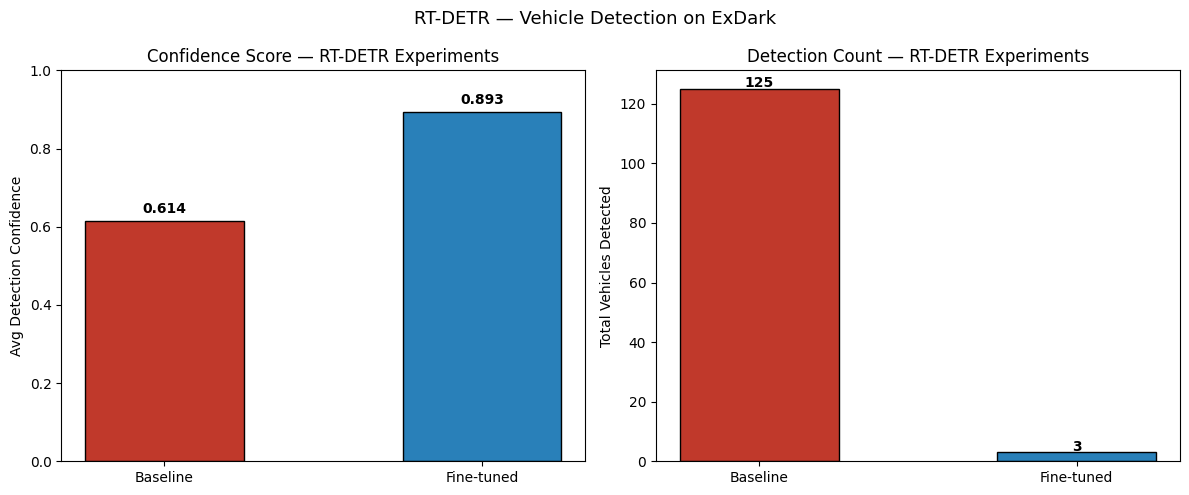


Model                  Avg Conf   Detections
─────────────────────────────────────────────
Baseline                  0.614          125
Fine-tuned                0.893            3 ← best


In [ ]:
import matplotlib.pyplot as plt

avg_base, count_base = 0.614, 125
avg_ft,   count_ft   = 0.893, 3

bar_labels = ["Baseline", "Fine-tuned"]
bar_confs  = [avg_base, avg_ft]
bar_counts = [count_base, count_ft]
bar_colors = ["#c0392b", "#2980b9"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

b1 = ax1.bar(bar_labels, bar_confs, color=bar_colors, width=0.5, edgecolor="black")
ax1.set_ylim(0, 1.0)
ax1.set_ylabel("Avg Detection Confidence")
ax1.set_title("Confidence Score — RT-DETR Experiments")
for bar, val in zip(b1, bar_confs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", fontweight="bold")

b2 = ax2.bar(bar_labels, bar_counts, color=bar_colors, width=0.5, edgecolor="black")
ax2.set_ylabel("Total Vehicles Detected")
ax2.set_title("Detection Count — RT-DETR Experiments")
for bar, val in zip(b2, bar_counts):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha="center", fontweight="bold")

plt.suptitle("RT-DETR — Vehicle Detection on ExDark", fontsize=13)
plt.tight_layout()
plt.savefig("rtdetr_summary_chart.png", dpi=150)
plt.show()

print(f"\n{'Model':<20} {'Avg Conf':>10} {'Detections':>12}")
print("─" * 45)
for name, c, d in zip(bar_labels, bar_confs, bar_counts):
    best_tag = " ← best" if c == max(bar_confs) else ""
    print(f"{name:<20} {c:>10.3f} {d:>12}{best_tag}")

In [ ]:
# ── Best Result: Experiment 2 (RT-DETR Fine-tuned) ─────
# Download weights from Google Drive:
# https://drive.google.com/drive/folders/1NZX5AOPGyUxuWpU38OSE_gmHzSadi2DZ?usp=sharing
# Place rtdetr_finetune_best.pt in the same folder as this notebook

from ultralytics import RTDETR
model_best = RTDETR("rtdetr_finetune_best.pt")